# Task 2.1: Dataset Selection and Setup

**Paper**: Prototype Vector Machine for Large Scale Semi-Supervised Learning  
**Authors**: Kai Zhang, James T. Kwok, Bahram Parvin  
**Venue**: ICML 2009  
**Student**: Ritesh Patil (230056)

## Dataset Choice and Justification

I chose the **Two Moons** dataset generated via `sklearn.datasets.make_moons` with 1000 samples and added Gaussian noise. This dataset is appropriate for the Prototype Vector Machine (PVM) because PVM is a semi-supervised classification method designed for graph-based learning on data with non-linear decision boundaries, which is exactly what Two Moons provides — two interleaving half-circles that cannot be separated by a linear classifier. The paper itself uses a 2-moon dataset as one of its 15 benchmarks (Table 1, row "2-moon(1000/2)"), making it directly relevant for comparison. The limitation compared to the paper's datasets is that Two Moons has only 2 features and is relatively simple; the paper also tests on higher-dimensional datasets like digit images (241 or 784 dimensions) and text data (11960 dimensions) where manifold structure is more complex. However, the 2D nature of Two Moons allows us to visualize the decision boundary and understand what PVM is doing, which is valuable for a reproduction study.

In [1]:
# =============================================
# Configuration and Random Seeds
# =============================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Hyperparameters (defined in one place)
N_SAMPLES = 1000      # Total number of data points
NOISE = 0.15          # Gaussian noise added to moons
N_LABELED_PER_CLASS = 5  # Number of labeled points per class (very few, to test SSL)

print(f"Random seed: {RANDOM_SEED}")
print(f"Total samples: {N_SAMPLES}")
print(f"Noise level: {NOISE}")
print(f"Labeled per class: {N_LABELED_PER_CLASS}")

Random seed: 42
Total samples: 1000
Noise level: 0.15
Labeled per class: 5


The cell above sets the random seed and defines all key hyperparameters in one place for reproducibility. We use 1000 samples with only 5 labeled per class (10 total labeled, 990 unlabeled), mimicking the semi-supervised scenario in the paper.

In [2]:
# =============================================
# Generate and Preprocess the Two Moons Dataset
# =============================================
X, y_true = make_moons(n_samples=N_SAMPLES, noise=NOISE, random_state=RANDOM_SEED)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Create semi-supervised labels: mask most labels as -1 (unlabeled)
y_ssl = -1 * np.ones(N_SAMPLES, dtype=int)  # -1 means unlabeled

# Pick labeled indices: N_LABELED_PER_CLASS from each class
labeled_indices = []
for cls in [0, 1]:
    cls_indices = np.where(y_true == cls)[0]
    chosen = np.random.choice(cls_indices, size=N_LABELED_PER_CLASS, replace=False)
    labeled_indices.extend(chosen)
labeled_indices = np.array(labeled_indices)

y_ssl[labeled_indices] = y_true[labeled_indices]

print(f"Dataset shape: {X.shape}")
print(f"Number of labeled samples: {np.sum(y_ssl >= 0)}")
print(f"Number of unlabeled samples: {np.sum(y_ssl < 0)}")
print(f"Class distribution (true): {np.bincount(y_true)}")

Dataset shape: (1000, 2)
Number of labeled samples: 10
Number of unlabeled samples: 990
Class distribution (true): [500 500]


This cell generates the Two Moons dataset, standardizes the features using StandardScaler, and creates the semi-supervised label setup. Out of 1000 points, only 10 are labeled (5 per class). The remaining 990 points have their labels masked to -1, simulating the SSL scenario. This matches the paper's setup where `l << u` (labeled much fewer than unlabeled).

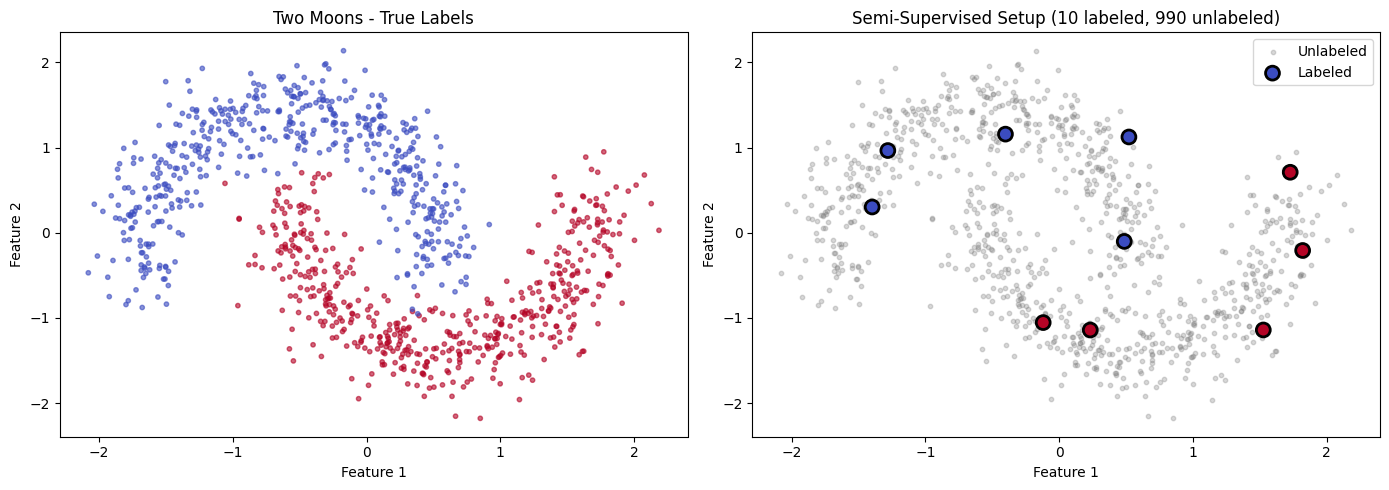

Saved: /Users/aloksinghtomar/Desktop/aml2/230056_midsem/partB/results/dataset_visualization.png


In [3]:
# =============================================
# Visualize the Dataset
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: True labels
axes[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='coolwarm', s=10, alpha=0.6)
axes[0].set_title('Two Moons - True Labels')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# Plot 2: SSL setup (labeled vs unlabeled)
unlabeled_mask = y_ssl < 0
axes[1].scatter(X[unlabeled_mask, 0], X[unlabeled_mask, 1], c='gray', s=10, alpha=0.3, label='Unlabeled')
axes[1].scatter(X[labeled_indices, 0], X[labeled_indices, 1], c=y_true[labeled_indices], 
                cmap='coolwarm', s=100, edgecolors='black', linewidth=2, label='Labeled', zorder=5)
axes[1].set_title('Semi-Supervised Setup (10 labeled, 990 unlabeled)')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()

plt.tight_layout()
plt.savefig('/Users/aloksinghtomar/Desktop/aml2/230056_midsem/partB/results/dataset_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: /Users/aloksinghtomar/Desktop/aml2/230056_midsem/partB/results/dataset_visualization.png")

This visualization shows the Two Moons dataset from two perspectives: the left plot shows all true labels (which are hidden from the algorithm), and the right plot shows the semi-supervised setup with only 10 labeled points highlighted. The challenge for PVM is to correctly classify the 990 gray (unlabeled) points using only the 10 labeled ones plus the graph structure.